In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

here = Path.cwd()
candidates = [here, *here.parents]
DATA_PATH = None
for base in candidates:
    hit = base / "clean_data" / "Model_Ready.csv"
    if hit.exists():
        DATA_PATH = hit
        break

if DATA_PATH is None:
    print("Could not find clean_data/Model_Ready.csv by climbing up from:")
    print("  ", here)
    print("Searching the whole project for it instead...")
    # last resort: search everywhere under the top-most parent
    matches = list(candidates[-1].rglob("Model_Ready.csv"))
    print("Found these:", matches)
else:
    print("Found file at:", DATA_PATH)

    df = pd.read_csv(DATA_PATH, parse_dates=["month"])
    df = df.sort_values("month").set_index("month")
    df = df.asfreq("MS")

    print("Date range:", df.index.min().date(), "->", df.index.max().date())
    print("Rows:", len(df))
    print("Missing target values:", df["total_people_served"].isna().sum())

Found file at: /Users/divena/coding projects/mse-401-team-6/clean_data/Model_Ready.csv
Date range: 2015-01-01 -> 2026-06-01
Rows: 138
Missing target values: 0


In [25]:
TARGET          = "total_people_served"
SEASONAL_PERIOD = 12            # monthly data -> yearly seasonality
TRAIN_END       = "2025-06-01"  # training ends June 2025
TEST_START      = "2025-07-01"  # test set: July 2025 onwards

# the two time ranges differ ONLY in where training starts
TIME_RANGES = {
    "TR1 (2019 start)": "2019-01-01",
    "TR2 (2022 start)": "2022-01-01",
}

series = df[TARGET]

In [26]:
def split_train_test(s, train_start, train_end, test_start):
    train = s.loc[train_start:train_end]
    test  = s.loc[test_start:]
    return train, test

def naive_forecast(train, test):
    # naive: every future value = last observed training value (flat line)
    return pd.Series(train.iloc[-1], index=test.index)

def seasonal_naive_forecast(train, test, m):
    # seasonal naive: repeat the last full season across the horizon
    last_season = train.iloc[-m:].values
    reps  = int(np.ceil(len(test) / m))
    tiled = np.tile(last_season, reps)[:len(test)]
    return pd.Series(tiled, index=test.index)

In [27]:
from sklearn.metrics import r2_score

def evaluate(actual, predicted):
    actual, predicted = actual.align(predicted, join="inner")
    err = actual - predicted
    return {
        "MAE":    round(np.mean(np.abs(err)), 1),
        "RMSE":   round(np.sqrt(np.mean(err**2)), 1),
        "WAPE %": round(np.sum(np.abs(err)) / np.sum(np.abs(actual)) * 100, 2),
        "R2":     round(r2_score(actual, predicted), 3),
    }

In [28]:
results = []

for label, train_start in TIME_RANGES.items():
    train, test = split_train_test(series, train_start, TRAIN_END, TEST_START)

    fc_naive  = naive_forecast(train, test)
    fc_snaive = seasonal_naive_forecast(train, test, SEASONAL_PERIOD)

    results.append({"time_range": label, "model": "Naive",          **evaluate(test, fc_naive)})
    results.append({"time_range": label, "model": "Seasonal Naive", **evaluate(test, fc_snaive)})

results_df = pd.DataFrame(results)
results_df

,time_range,model,MAE,RMSE,WAPE %,R2
0,TR1 (2019 start),Naive,2621.2,3005.2,4.69,-0.001
1,TR1 (2019 start),Seasonal Naive,4151.6,5624.1,7.43,-2.505
2,TR2 (2022 start),Naive,2621.2,3005.2,4.69,-0.001
3,TR2 (2022 start),Seasonal Naive,4151.6,5624.1,7.43,-2.505


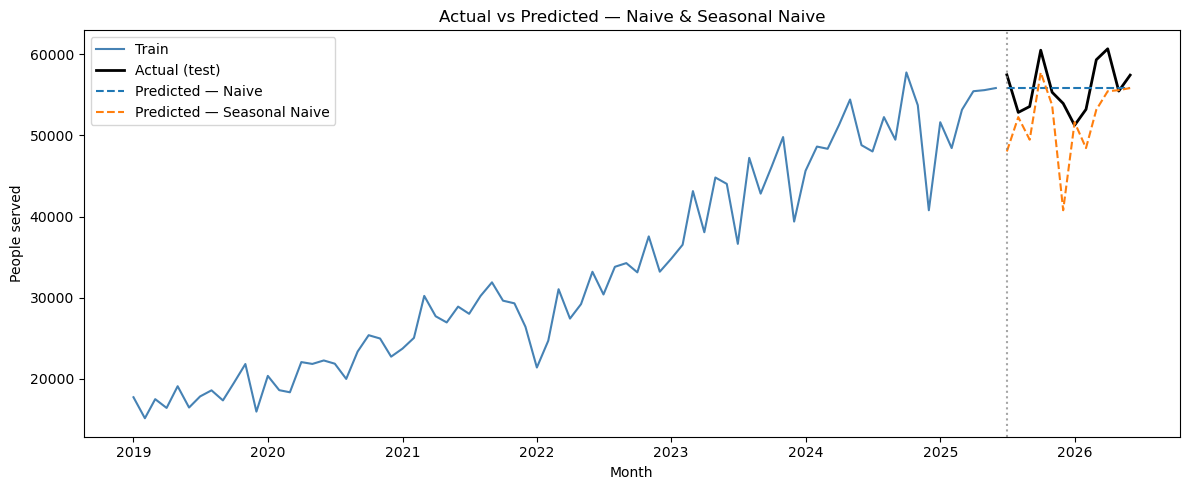

In [29]:
train, test = split_train_test(series, TIME_RANGES["TR1 (2019 start)"], TRAIN_END, TEST_START)
fc_naive  = naive_forecast(train, test)
fc_snaive = seasonal_naive_forecast(train, test, SEASONAL_PERIOD)

plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train", color="steelblue")
plt.plot(test.index,  test,  label="Actual (test)", color="black", linewidth=2)
plt.plot(fc_naive.index,  fc_naive,  label="Predicted — Naive", linestyle="--")
plt.plot(fc_snaive.index, fc_snaive, label="Predicted — Seasonal Naive", linestyle="--")
plt.axvline(pd.Timestamp(TEST_START), color="grey", linestyle=":", alpha=0.7)
plt.title("Actual vs Predicted — Naive & Seasonal Naive")
plt.xlabel("Month"); plt.ylabel("People served")
plt.legend(); plt.tight_layout()
plt.show()

## Naive Baseline Results - Summary

**Target:** `total_people_served` (monthly, agency level)
**Test period:** July 2025 onwards
**Baselines fit:** Naive and Seasonal Naive, across two training ranges (2019 start, 2022 start)
**Metrics:** MAE, RMSE, WAPE, R²

### Key Takeaways

- **Naive is the stronger baseline** (4.69% WAPE vs Seasonal Naive's 7.43%). The series is **trend-dominated** — it climbs steadily and plateaus near the split. Seasonal Naive replays last year's lower values and undershoots badly, while Naive holds the current (higher) level and lands closer.
- **R² is essentially zero for Naive (−0.001) and strongly negative for Seasonal Naive (−2.505).** Neither method models trend, so neither beats the test-period mean on variance explained. Seasonal Naive's large negative R² confirms it forecasts substantially worse than a flat average by projecting outdated seasonal levels.
- **Both time ranges give identical results.** Expected: Naive uses only the last training value and Seasonal Naive only the last 12 months, both of which share the same June 2025 endpoint. The training start date only matters for models that learn from the full history.
- **Feature importance: N/A** — Naive and Seasonal Naive use only the target's own history and have no external input features.
- **Implication for next steps:** Neither baseline models trend. Holt-Winters handles trend *and* seasonality jointly — judged against this ~4.7% WAPE floor.